In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Quotes Dataset.csv')
df.head()

,Number,Quote,Author
0,1,The only thing we have to fear is fear itself.,Franklin D. Roosevelt
1,2,The truth will set you free.,The Bible
2,3,To be yourself in a world that is constantly t...,Ralph Waldo Emerson
3,4,"Success is not final, failure is not fatal: It...",Winston S. Churchill
4,5,The only way to do great work is to love what ...,Steve Jobs


In [3]:
df.shape

(725, 3)

In [4]:
df.dropna(subset=['Quote'], inplace=True)

In [5]:
sentence = df['Quote']
sentence

,Quote
0,The only thing we have to fear is fear itself.
1,The truth will set you free.
2,To be yourself in a world that is constantly t...
3,"Success is not final, failure is not fatal: It..."
4,The only way to do great work is to love what ...
...,...
720,Believe you can and you're halfway there.
721,The mind is everything. What you think you bec...
722,"I have not failed. I've just found 10,000 ways..."
723,A journey of a thousand miles begins with a si...


In [6]:
import string
sentence = df['Quote'].astype(str)

In [7]:
translator = str.maketrans('', '', string.punctuation + string.digits)
sentence = sentence.str.translate(translator)

print(f"Total sentences: {len(sentence)}")
print(sentence.head(3))

Total sentences: 725
0        The only thing we have to fear is fear itself
1                          The truth will set you free
2    To be yourself in a world that is constantly t...
Name: Quote, dtype: object


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 1000

In [9]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token = '<OOV>')
tokenizer.fit_on_texts(sentence)

In [10]:
tokenizer

In [11]:
word_index = tokenizer.word_index
print(len(word_index))
list(word_index.items())[:10]

245


[('<OOV>', 1),
 ('you', 2),
 ('the', 3),
 ('to', 4),
 ('it', 5),
 ('of', 6),
 ('a', 7),
 ('can', 8),
 ('is', 9),
 ('be', 10)]

In [12]:
sequence = tokenizer.texts_to_sequences(sentence)
sequence[3]

[26, 9, 15, 145, 146, 9, 15, 147, 5, 9, 3, 148, 4, 149, 21, 150]

In [13]:
X = []
y = []

for seq in sequence:
    for i in range(1, len(seq)):
      input_seq = seq[:i]
      output_seq = seq[i]
      X.append(input_seq)
      y.append(output_seq)

In [14]:
X

[[3],
 [3, 24],
 [3, 24, 46],
 [3, 24, 46, 23],
 [3, 24, 46, 23, 11],
 [3, 24, 46, 23, 11, 4],
 [3, 24, 46, 23, 11, 4, 113],
 [3, 24, 46, 23, 11, 4, 113, 9],
 [3, 24, 46, 23, 11, 4, 113, 9, 113],
 [3],
 [3, 142],
 [3, 142, 104],
 [3, 142, 104, 143],
 [3, 142, 104, 143, 2],
 [4],
 [4, 10],
 [4, 10, 27],
 [4, 10, 27, 102],
 [4, 10, 27, 102, 7],
 [4, 10, 27, 102, 7, 103],
 [4, 10, 27, 102, 7, 103, 21],
 [4, 10, 27, 102, 7, 103, 21, 9],
 [4, 10, 27, 102, 7, 103, 21, 9, 115],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117, 2],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117, 2, 105],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117, 2, 105, 28],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117, 2, 105, 28, 9],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117, 2, 105, 28, 9, 3],
 [4, 10, 27, 102, 7, 103, 21, 9, 115, 116, 4, 117, 2, 105, 28, 9,

In [15]:
max_len = max(len(x) for x in X)
print(max_len)

23


In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_padded = pad_sequences(X, maxlen = max_len, padding = 'pre', truncating = 'pre')
X_padded

array([[ 0,  0,  0, ...,  0,  0,  3],
       [ 0,  0,  0, ...,  0,  3, 24],
       [ 0,  0,  0, ...,  3, 24, 46],
       ...,
       [ 0,  0,  0, ..., 17, 65, 45],
       [ 0,  0,  0, ..., 65, 45, 40],
       [ 0,  0,  0, ..., 45, 40, 39]], dtype=int32)

In [17]:
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y, num_classes=vocab_size)
y_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN, Input, GRU

# **SIMPLERNN MODEL**

In [19]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

embedding_dim = 100
rnn_units = 256

rnn_model = Sequential()
rnn_model.add(
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim, input_length=max_len)
)
rnn_model.add(Dropout(0.3)) # Increased Dropout rate

rnn_model.add(
    SimpleRNN(units=rnn_units, activation='tanh')
)
rnn_model.add(Dropout(0.3)) # Increased Dropout rate

rnn_model.add(
    Dense(units=vocab_size, activation='softmax')
)

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [20]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
epochs = 100
batch_size = 64

def get_early_stopping():
  return EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose = 1)

hist = rnn_model.fit(
    X_padded, y_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[get_early_stopping()], # Fixed: Called the function to get the EarlyStopping instance
    verbose=1

)

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.0647 - loss: 4.8195 - val_accuracy: 0.0893 - val_loss: 4.2343
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3131 - loss: 3.4260 - val_accuracy: 0.8458 - val_loss: 1.3344
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8671 - loss: 0.9959 - val_accuracy: 0.9583 - val_loss: 0.2211
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9115 - loss: 0.5334 - val_accuracy: 0.9788 - val_loss: 0.1063
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.4048 - val_accuracy: 0.9788 - val_loss: 0.0752
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9267 - loss: 0.3285 - val_accuracy: 0.9788 - val_loss: 0.0646
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9346 - loss: 0.2712 - val_accuracy: 0.9788 - val_loss: 0.0563
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9427 - loss: 0.2262 - val_accuracy: 0.9795 - 

### **SimpleRNN Model: Training and Validation Metrics (After Overfitting Fixes)**

# **LSTM MODEL**

In [22]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

lstm_model = Sequential()
lstm_model.add(
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim, input_length=max_len)
)
lstm_model.add(Dropout(0.3))

lstm_model.add(
    LSTM(units=rnn_units, activation='tanh', kernel_regularizer=l2(0.0001))
)
lstm_model.add(Dropout(0.3))

lstm_model.add(
    Dense(units=vocab_size, activation='softmax', kernel_regularizer=l2(0.0001))
)

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
epochs = 100
batch_size = 128

early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose = 1
)

history = lstm_model.fit(
    X_padded, y_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stopping], # Fixed: Called the function to get the EarlyStopping instance
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.0659 - loss: 5.1779 - val_accuracy: 0.0827 - val_loss: 4.3457
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0817 - loss: 4.5061 - val_accuracy: 0.0827 - val_loss: 4.2093
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1253 - loss: 4.1697 - val_accuracy: 0.1774 - val_loss: 3.6636
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2313 - loss: 3.5237 - val_accuracy: 0.3627 - val_loss: 2.8454
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4036 - loss: 2.7659 - val_accuracy: 0.5486 - val_loss: 2.0643
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6192 - loss: 2.1148 - val_accuracy: 0.8451 - val_loss: 1.4379
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7738 - loss: 1.6255 - val_accuracy: 0.8749 - val_loss: 1.0176
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8249 - loss: 1.2997 - val_accuracy: 0.

In [24]:
gru_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Dropout(0.3),
    GRU(units=rnn_units, activation='tanh', kernel_regularizer=l2(0.0001)),
    Dropout(0.3),
    Dense(units=vocab_size, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
gru_hist = gru_model.fit(
    X_padded, y_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[get_early_stopping()],
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0720 - loss: 5.2512 - val_accuracy: 0.0827 - val_loss: 4.2895
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0943 - loss: 4.4033 - val_accuracy: 0.1370 - val_loss: 3.9080
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2395 - loss: 3.5749 - val_accuracy: 0.4024 - val_loss: 2.5463
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5506 - loss: 2.1830 - val_accuracy: 0.8167 - val_loss: 1.1160
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8206 - loss: 1.1616 - val_accuracy: 0.9385 - val_loss: 0.4585
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8782 - loss: 0.7503 - val_accuracy: 0.9517 - val_loss: 0.2671
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8997 - loss: 0.5804 - val_accuracy: 0.9729 - val_loss: 0.1906
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9111 - loss: 0.4848 - val_accuracy: 0.

In [27]:
lstm_model.save("lstm_model.keras")

In [29]:
gru_model.save('GRU_Model.keras')

In [30]:
index_to_word = {}
for word, index in word_index.items():
  index_to_word[index] = word

index_to_word

{1: '<OOV>',
 2: 'you',
 3: 'the',
 4: 'to',
 5: 'it',
 6: 'of',
 7: 'a',
 8: 'can',
 9: 'is',
 10: 'be',
 11: 'have',
 12: 'and',
 13: 'but',
 14: 'i',
 15: 'not',
 16: 'everything',
 17: 'always',
 18: 'cant',
 19: 'my',
 20: 'do',
 21: 'that',
 22: 'what',
 23: 'we',
 24: 'only',
 25: 'life',
 26: 'success',
 27: 'yourself',
 28: 'else',
 29: 'work',
 30: 'dont',
 31: 'if',
 32: 'change',
 33: 'your',
 34: 'as',
 35: 'youre',
 36: 'believe',
 37: 'ive',
 38: 'on',
 39: 'its',
 40: 'until',
 41: 'with',
 42: 'one',
 43: 'mind',
 44: 'become',
 45: 'impossible',
 46: 'thing',
 47: 'making',
 48: 'miss',
 49: 'shots',
 50: 'take',
 51: 'halfway',
 52: 'there',
 53: 'why',
 54: 'failed',
 55: 'just',
 56: 'found',
 57: 'ways',
 58: 'wont',
 59: 'journey',
 60: 'thousand',
 61: 'miles',
 62: 'begins',
 63: 'step',
 64: 'think',
 65: 'seems',
 66: 'done',
 67: 'dream',
 68: 'are',
 69: 'keep',
 70: 'direction',
 71: 'wind',
 72: 'adjust',
 73: 'sails',
 74: 'reach',
 75: 'destination',
 7

LSTM_Model prediction

In [164]:

def predictor(model, tokenizer, text, max_len):
  text = text.lower()
  seq = tokenizer.texts_to_sequences([text])[0]
  seq = pad_sequences([seq], maxlen=max_len, padding='pre', truncating='pre')

  prediction = model.predict(seq, verbose=0)
  prediction_word = index_to_word[np.argmax(prediction)]
  return prediction_word

In [165]:
seed_text = 'can only things standings in'
next_word = predictor(lstm_model, tokenizer, seed_text, max_len)
print(next_word)

the


GRU_Model Prediction

In [166]:
seed_text = 'my name really simple '
next_word = predictor(gru_model, tokenizer, seed_text, max_len)
print(next_word)

but


now we perdict a mulitiple words

In [168]:
def generate_text(model, tokenizer, seed_text, max_len, num_words):
  text = seed_text
  for _ in range(num_words):
    next_words = predictor(model, tokenizer, text, max_len)
    if next_words == " ":
      break
    text += " " + next_words
  return text

In [172]:
seed_word = "hii woh are you"
generated_output = generate_text(lstm_model, tokenizer, seed_word, max_len, 10)
print(generated_output)

hii woh are you can and youre halfway there it is the story you


In [174]:
import pickle

with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)


In [175]:
with open('max_len.pickle', 'wb') as f:
    pickle.dump(max_len, f)

In [176]:
# Extracting and displaying the best validation metrics for each model
print("--- SimpleRNN Model ---")
# The best epoch for SimpleRNN was 27 (0-indexed, so index 26)
print(f"Best Validation Loss: {hist.history['val_loss'][26]:.4f}")
print(f"Best Validation Accuracy: {hist.history['val_accuracy'][26]:.4f}")

print("\n--- LSTM Model ---")
# The best epoch for LSTM was 75 (0-indexed, so index 74)
print(f"Best Validation Loss: {history.history['val_loss'][74]:.4f}")
print(f"Best Validation Accuracy: {history.history['val_accuracy'][74]:.4f}")

print("\n--- GRU Model ---")
# The best epoch for GRU was 98 (0-indexed, so index 97)
print(f"Best Validation Loss: {gru_hist.history['val_loss'][97]:.4f}")
print(f"Best Validation Accuracy: {gru_hist.history['val_accuracy'][97]:.4f}")

--- SimpleRNN Model ---
Best Validation Loss: 0.0314
Best Validation Accuracy: 0.9795

--- LSTM Model ---
Best Validation Loss: 0.1389
Best Validation Accuracy: 0.9788

--- GRU Model ---
Best Validation Loss: 0.0361
Best Validation Accuracy: 0.9795


## Model Performance Plots

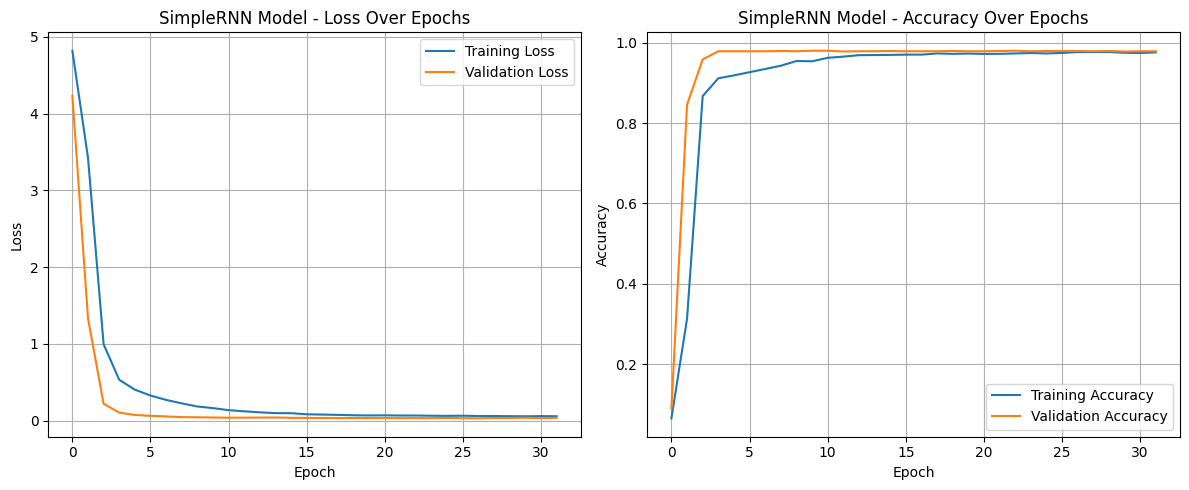

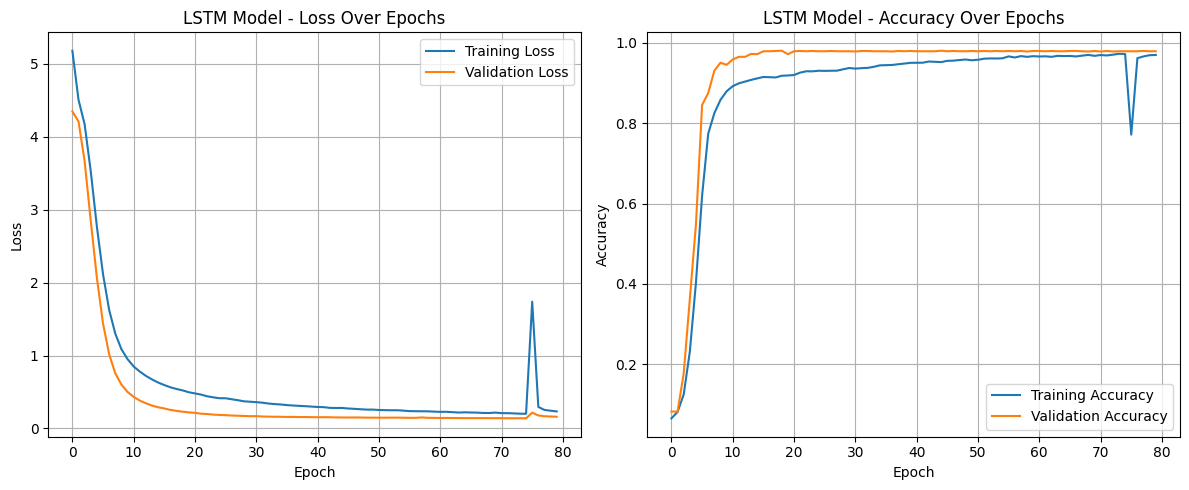

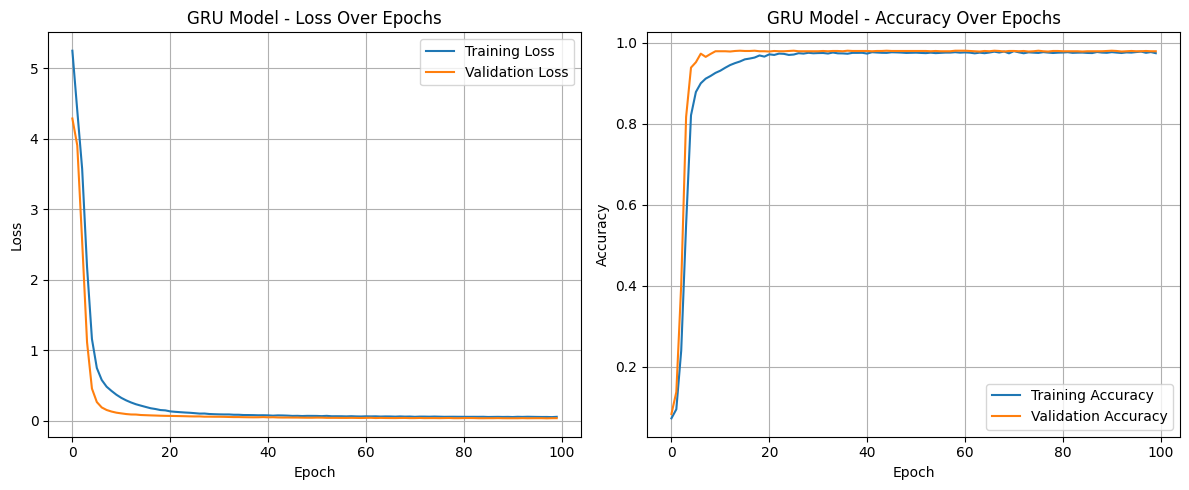

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot training history
def plot_history(history_obj, model_name):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history_obj.history['loss'], label='Training Loss')
    plt.plot(history_obj.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history_obj.history['accuracy'], label='Training Accuracy')
    plt.plot(history_obj.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot for SimpleRNN Model
plot_history(hist, 'SimpleRNN Model')

# Plot for LSTM Model
plot_history(history, 'LSTM Model')

# Plot for GRU Model
plot_history(gru_hist, 'GRU Model')